<a href="https://www.kaggle.com/code/eavprog/absolute-fx-insights-maximum-drawdown-risk-rank?scriptVersionId=303795419" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 📉 Исследование валютных рисков: Максимальная просадка (Maximum Drawdown)

### Анализ устойчивости на основе абсолютных курсов проекта [abscur.ru](https://www.abscur.ru)

Большинство инвесторов смотрят только на доходность или волатильность, но **Maximum Drawdown (MDD)** — это то, что определяет выживаемость портфеля. Этот показатель отвечает на самый болезненный вопрос: *«Сколько я бы потерял в худший момент времени?»*.

---

### 💡 Что такое «Абсолютный курс»?
В отличие от привычных валютных пар (например, USD/RUB) **абсолютный курс** рассчитывается относительно широкой и диверсифицированной корзины из всех мировых валют сразу.

* **Зачем это нужно?** Это позволяет исключить влияние «сильного доллара» или «слабого евро» и увидеть реальную, очищенную от рыночного шума стоимость конкретной национальной валюты.
* **Результат:** Если абсолютный курс падает, значит, валюта теряет ценность по отношению к мировой экономике в целом, а не просто к какому-то одному активу.

---

### 🚀 Какие задачи решает это исследование:
* **Оценка «дна»:** Поиск исторически минимальных точек падения для каждой валюты.
* **Сравнение устойчивости:** Выявление фаворитов (стабильных систем) и аутсайдеров (валют с хроническим обесценением).
* **Стресс-тестирование:** Анализ поведения активов на горизонтах от 1 месяца до 10 лет.

### 🛠 Используемый инструментарий:
1. **Данные:** Ежедневно обновляемая база абсолютных курсов [Abscur](https://www.abscur.ru).
2. **Алгоритмы:** Честный расчет временных интервалов с использованием `Pandas DateOffset`.
3. **Визуализация:** Интерактивные таблицы (Heatmaps) и диаграммы распределения рисков.

---
> **Интерактивность:** Все тикеры в таблицах и списках ниже являются гиперссылками. Кликнув на них, вы мгновенно перейдете к детальным историческим графикам на сайте [abscur.ru](https://www.abscur.ru).

# 📊 Часть 1: Загрузка и первичный анализ данных

В этом разделе происходит инициализация окружения и загрузка основного датасета **абсолютных валютных курсов**. Эти данные уникальны тем, что представляют стоимость валют не относительно одного «якоря» (как USD), а как абсолютное значение внутри диверсифицированной корзины.

**Основные задачи этапа:**
* Загрузка набора данных `abscur.csv` из родительского исследования (abscur2).
* Преобразование временных рядов для корректного исторического анализа.
* Проверка структуры тикеров валют (AED, ARS, RUB и др.).


In [1]:
import pandas as pd

# Путь к файлу из подключенного источника
file_path = '/kaggle/input/notebooks/eavprog/abscur2/abscur.csv'

# Загрузка данных
# Указываем parse_dates=['Date'], чтобы pandas сразу распознал колонку с датами
df = pd.read_csv(file_path, parse_dates=['Date'])

# Вывод первых 5 строк для проверки
df.head()

,Date,AED,ARS,AUD,BRL,CAD,CHF,CLP,CNY,COP,...,SAR,SEK,SGD,THB,TRY,TWD,UAH,USD,VND,ZAR
0,2006-07-27,3.898873,1.683188,10.838923,5.596155,12.292406,15.511809,0.024427,1.826801,0.006823,...,3.817188,1.655005,11.441205,0.436869,6.317244,0.443443,0.989638,14.320561,0.000673,1.282034
1,2006-07-28,3.898841,1.683174,10.838947,5.596110,12.292434,15.511844,0.024427,1.827150,0.006823,...,3.817157,1.655008,11.441231,0.436865,6.317193,0.443440,0.989630,14.320445,0.000673,1.282037
2,2006-07-31,3.898831,1.683169,10.838955,5.596095,12.292443,15.511855,0.024427,1.827266,0.006822,...,3.817146,1.655010,11.441239,0.436864,6.317176,0.443439,0.989628,14.320406,0.000673,1.282038
3,2006-08-01,3.898863,1.683183,10.838931,5.596140,12.292415,15.511820,0.024427,1.826917,0.006823,...,3.817177,1.655006,11.441214,0.436868,6.317227,0.443442,0.989636,14.320523,0.000673,1.282035
4,2006-08-02,3.898834,1.683171,10.838953,5.596099,12.292440,15.511852,0.024427,1.827231,0.006822,...,3.817149,1.655009,11.441237,0.436864,6.317181,0.443439,0.989628,14.320418,0.000673,1.282038


# 📉 Часть 2: Расчет и визуализация максимальной просадки (MDD)
В этой части мы определим функцию для расчета **Maximum Drawdown** — ключевого показателя риска, который измеряет наибольшее падение стоимости актива от локального максимума до последующего минимума. 

Мы визуализируем подводные камни (underwater chart) на примере одной из валют, чтобы наглядно увидеть периоды восстановления.

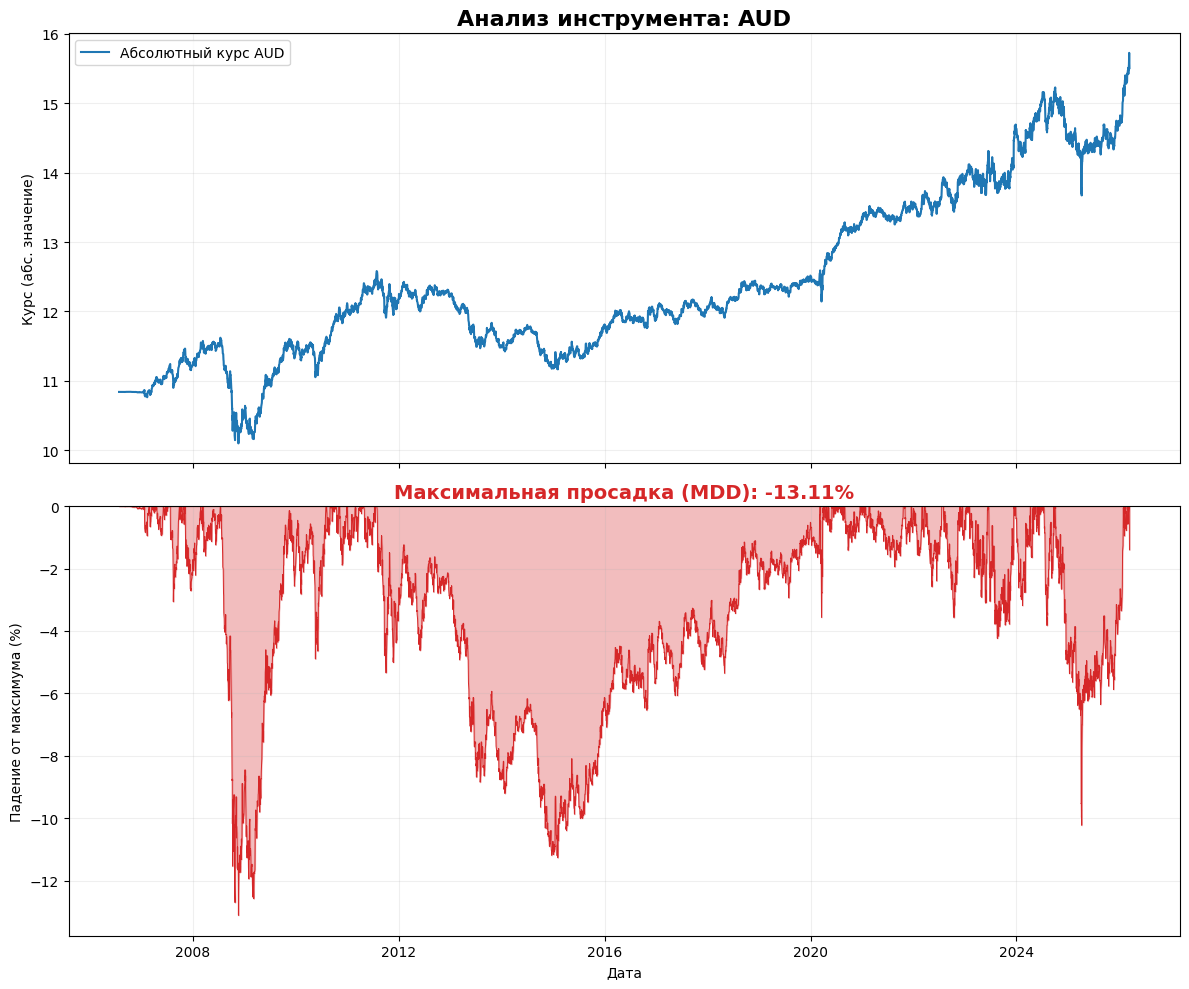

Случайно выбранный актив: AUD
Зафиксированный исторический MDD: -13.11%


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random

def calculate_mdd(series):
    """
    Функция для расчета максимальной просадки.
    Возвращает текущую просадку (drawdowns) и само значение MDD.
    """
    rolling_max = series.cummax()
    # Умножаем на 100, чтобы сразу получить проценты
    drawdowns = (series - rolling_max) / rolling_max * 100
    mdd = drawdowns.min()
    return drawdowns, mdd

# Убедимся, что дата в индексе (если еще не сделали)
if 'Date' in df.columns:
    df.set_index('Date', inplace=True)

# Выбираем случайный тикер из колонок датафрейма
available_tickers = df.columns.tolist()
random_ticker = random.choice(available_tickers)

target_series = df[random_ticker]

# Выполняем расчет
drawdowns, mdd_value = calculate_mdd(target_series)

# Визуализация
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Верхний график: Динамика абсолютного курса
ax1.plot(target_series.index, target_series, label=f'Абсолютный курс {random_ticker}', color='#1f77b4')
ax1.set_title(f'Анализ инструмента: {random_ticker}', fontsize=16, fontweight='bold')
ax1.set_ylabel('Курс (абс. значение)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)

# Нижний график: Подводный график просадок (в процентах)
ax2.fill_between(drawdowns.index, drawdowns, 0, color='#d62728', alpha=0.3, label='Просадка (Drawdown, %)')
ax2.plot(drawdowns.index, drawdowns, color='#d62728', linewidth=0.7)
ax2.set_ylabel('Падение от максимума (%)')
ax2.set_ylim(None, 0) # Ограничиваем сверху нулем для наглядности
ax2.set_title(f'Максимальная просадка (MDD): {mdd_value:.2f}%', color='#d62728', fontsize=14, weight='bold')
ax2.grid(True, alpha=0.2)

# Добавляем подпись оси X только для нижнего графика
plt.xlabel('Дата')

plt.tight_layout()
plt.show()

print(f"Случайно выбранный актив: {random_ticker}")
print(f"Зафиксированный исторический MDD: {mdd_value:.2f}%")

# 📊 Часть 3: Композитный рейтинг исторической просадки (Drawdown Matrix)

В этой таблице представлен расчет **Maximum Drawdown (MDD)** — ключевого показателя риска, отражающего максимальное падение стоимости валюты от локального пика до минимума за конкретный период. 

### Особенности методологии:
* **Честные интервалы:** Расчет периодов (от 1 месяца до 10 лет) выполняется по календарным датам, а не по количеству строк, что обеспечивает точность анализа временных рядов.
* **Скрытая интеллектуальная сортировка:** Валюты отсортированы по **суммарному рейтингу (рангу)** на всех временных горизонтах. Сверху находятся активы, которые системно демонстрируют наибольшую глубину падения (наивысший риск) как в краткосрочной, так и в долгосрочной перспективе.
* **Изолированная раскраска:** Цветовая шкала (Heatmap) применяется к каждому столбцу отдельно. Это позволяет мгновенно определить «аутсайдеров» внутри конкретного периода, не смешивая волатильность месяца с историческими просадками десятилетия.
* **Интерактивность:** Тикеры валют являются активными гиперссылками. Нажатие на тикер откроет детальный график абсолютного курса на сайте [abscur.ru](https://www.abscur.ru).

*Таблица позволяет инвесторам и аналитикам быстро выявлять наиболее рискованные валютные системы и оценивать их устойчивость к рыночным шокам.*

In [3]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import DateOffset

# 1. Функция честного расчета MDD
def get_mdd_by_date(series, start_date):
    subset = series[series.index >= start_date]
    if subset.empty: return np.nan
    rolling_max = subset.cummax()
    return ((subset - rolling_max) / rolling_max * 100).min()

# 2. Подготовка дат (от последней точки в данных)
last_date = df.index.max()
date_periods = {
    '1 мес': last_date - DateOffset(months=1),
    '3 мес': last_date - DateOffset(months=3),
    '6 мес': last_date - DateOffset(months=6),
    '1 год': last_date - DateOffset(years=1),
    '3 года': last_date - DateOffset(years=3),
    '5 лет': last_date - DateOffset(years=5),
    '10 лет': last_date - DateOffset(years=10)
}

# 3. Сбор данных
mdd_results = []
for ticker in df.columns:
    row = {'Валюта': ticker}
    for p_name, start_dt in date_periods.items():
        row[p_name] = get_mdd_by_date(df[ticker], start_dt)
    mdd_results.append(row)

mdd_table = pd.DataFrame(mdd_results).set_index('Валюта')

# 4. Логика скрытой сортировки по сумме рангов
# Рассчитываем ранги для каждого периода (меньшее значение MDD = 1-е место)
rank_table = mdd_table.rank(method='min', ascending=True)
# Добавляем временную колонку для сортировки
mdd_table['_rank_sum'] = rank_table.sum(axis=1)
# Сортируем и удаляем временную колонку
mdd_table = mdd_table.sort_values(by='_rank_sum', ascending=True).drop(columns=['_rank_sum'])

# 5. Функция для создания гиперссылок
def make_clickable(ticker):
    url = f"https://www.abscur.ru/p/2.html?abs={ticker}"
    # Используем target="_blank" для открытия в новой вкладке
    # Это наиболее надежный способ для Kaggle/Jupyter
    return f'<a href="{url}" target="_blank" rel="noopener noreferrer">{ticker}</a>'

# 6. Стилизация и вывод
styled_table = mdd_table.style.background_gradient(
    cmap='Reds_r', 
    axis=0
).format("{:.2f}%") \
 .format_index(make_clickable) \
 .set_caption(f"Рейтинг максимальной просадки (MDD) на {last_date.date()}. Сортировка по совокупному риску.")

styled_table

,1 мес,3 мес,6 мес,1 год,3 года,5 лет,10 лет
Валюта,,,,,,,
EGP,-10.13%,-11.03%,-11.72%,-11.72%,-41.56%,-66.41%,-79.91%
ARS,-2.90%,-3.07%,-10.61%,-30.28%,-85.65%,-92.51%,-98.73%
TRY,-0.58%,-4.69%,-7.82%,-20.47%,-55.47%,-80.21%,-91.38%
UAH,-1.56%,-5.62%,-7.59%,-10.94%,-16.83%,-30.07%,-34.77%
CLP,-4.56%,-5.15%,-5.15%,-7.92%,-16.28%,-24.40%,-27.91%
RUB,-2.13%,-3.89%,-5.87%,-9.56%,-26.36%,-39.36%,-39.36%
COP,-2.58%,-4.80%,-4.80%,-6.63%,-13.44%,-19.88%,-30.02%
KZT,-3.04%,-3.04%,-3.48%,-11.42%,-21.01%,-21.01%,-30.60%
JPY,-2.30%,-3.33%,-8.22%,-12.96%,-13.44%,-13.44%,-13.44%


# 📉 Часть 4: Визуальный анализ распределения рисков по периодам

Этот раздел переводит статистику в визуальную форму. Для каждого временного горизонта построена столбчатая диаграмма, где валюты ранжированы по уровню устойчивости.

**Структура анализа:**
* **Диаграммы просадок:** Наглядно показывают «глубину падения» активов. Тикеры расположены слева направо: от самых стабильных к самым падающим.
* **Синий цвет:** Обозначает основную массу валют и группу **Фаворитов** — активы с минимальной потерей стоимости.
* **Красный цвет:** Подсвечивает зону **Аутсайдеров** — 20% наиболее пострадавших валют в выбранном периоде.
* **Интерактивные списки:** Под каждым графиком расположены прямые ссылки на [abscur.ru](https://www.abscur.ru). Нажмите на тикер, чтобы мгновенно перейти к анализу истории курса.

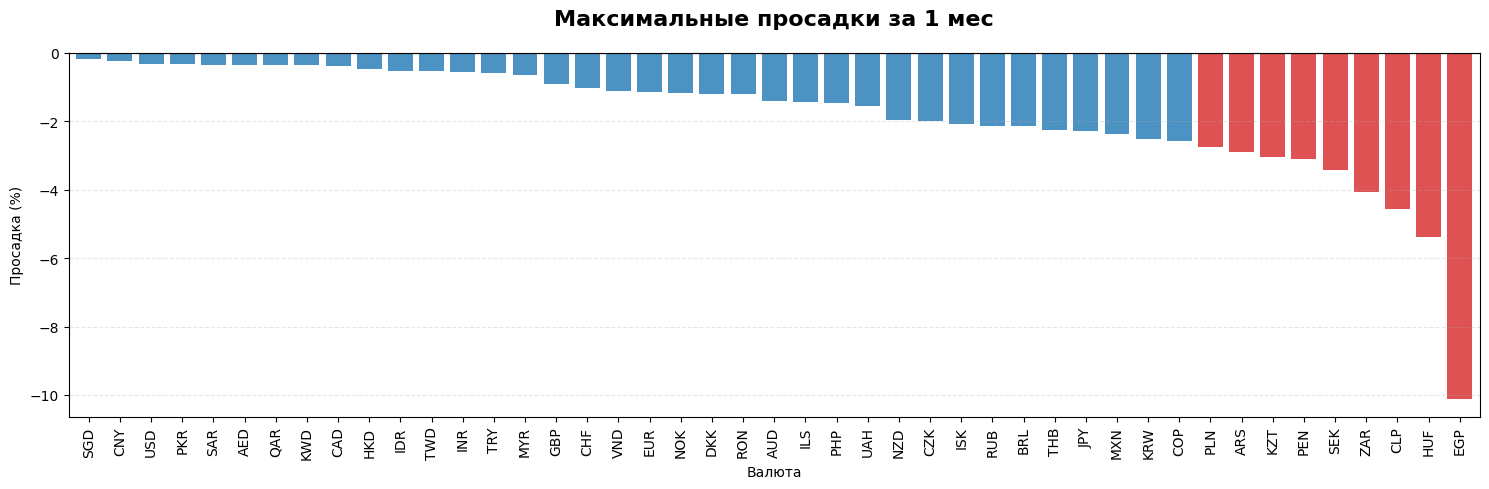

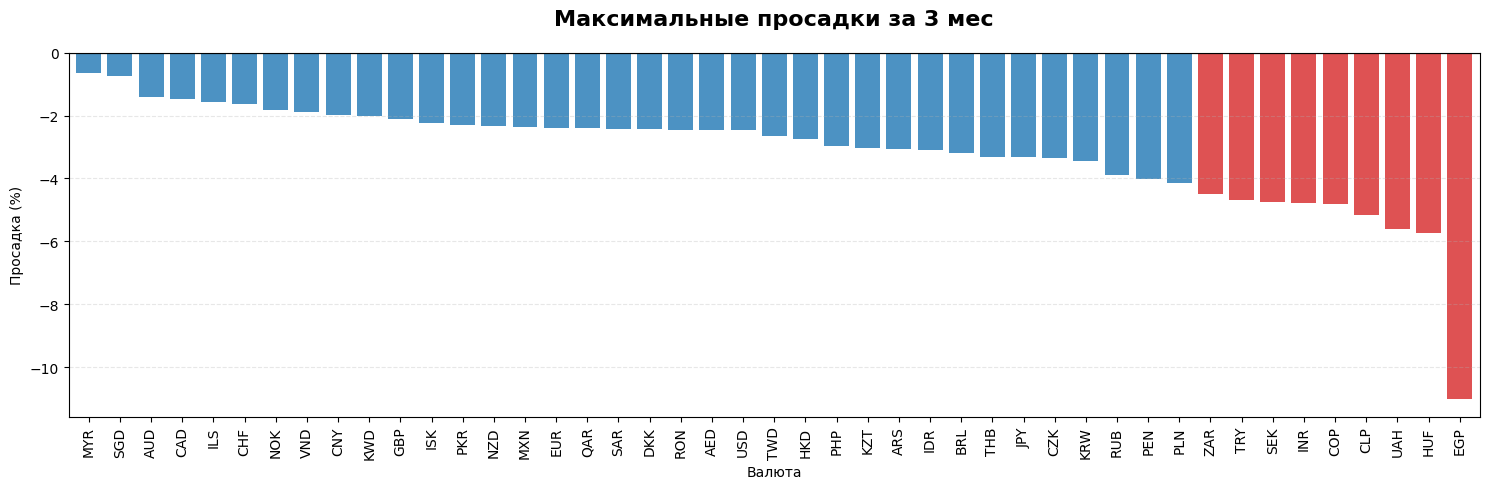

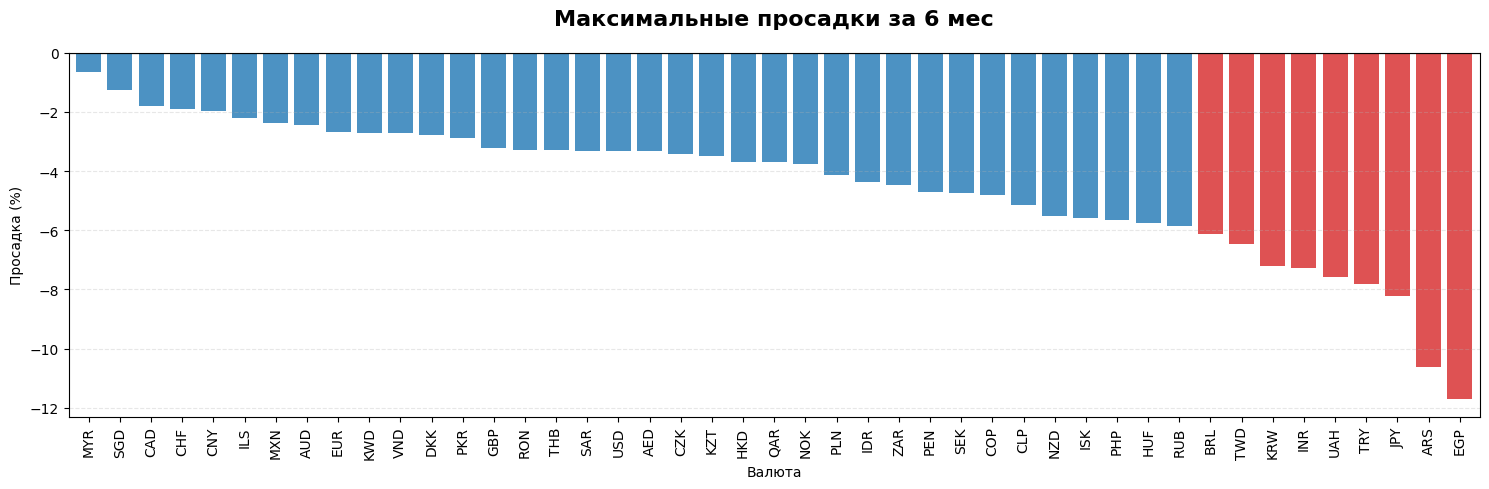

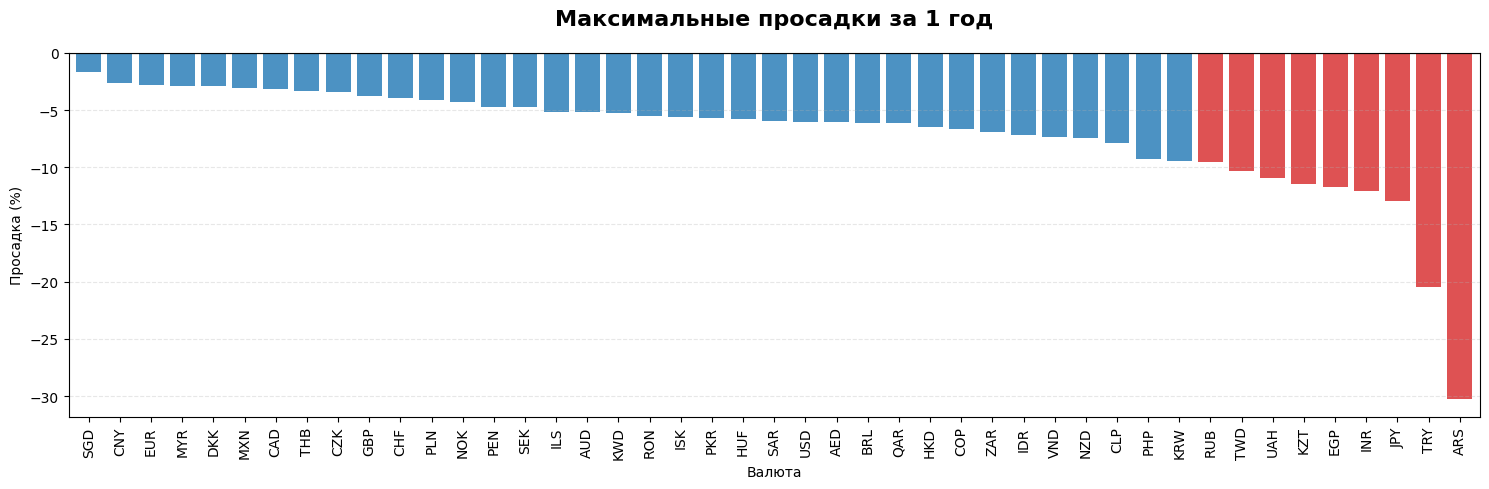

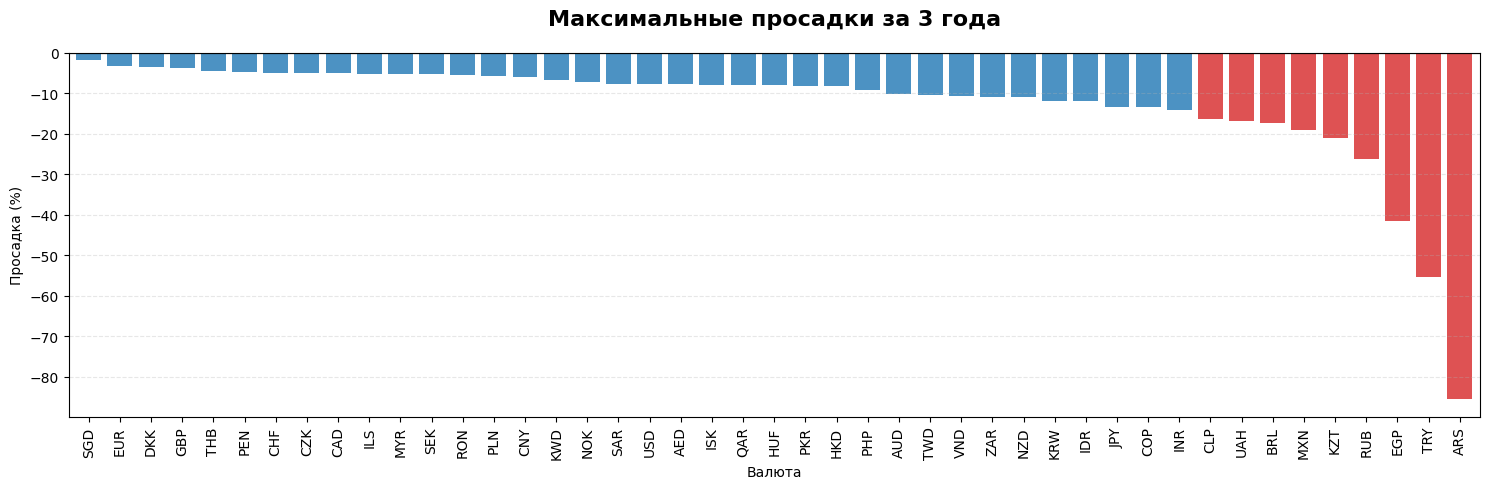

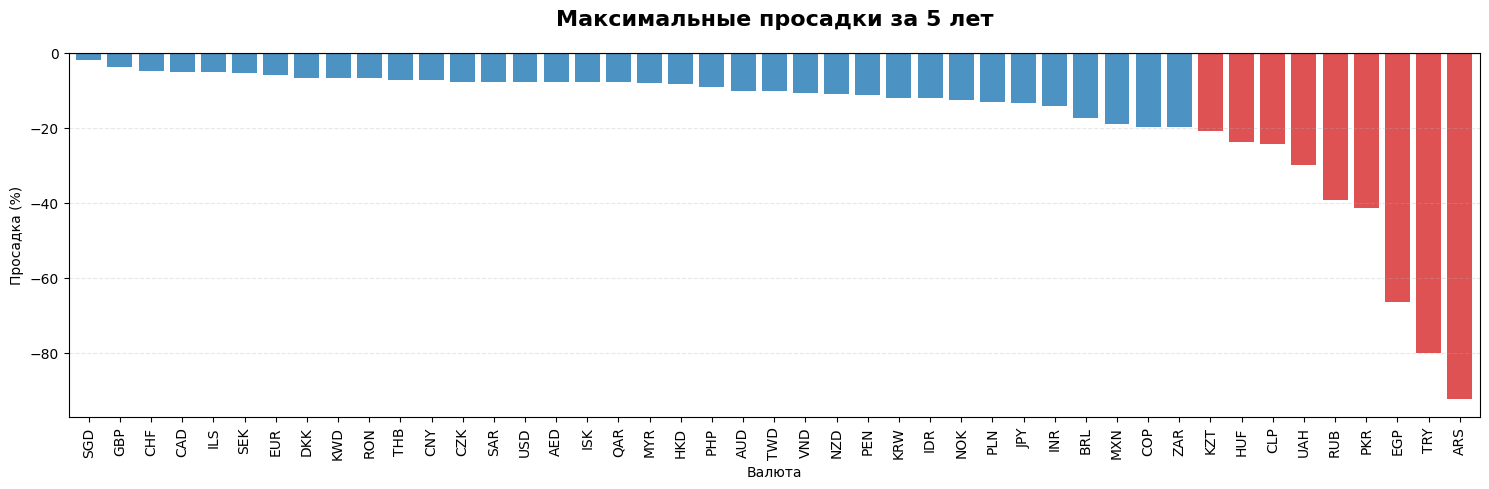

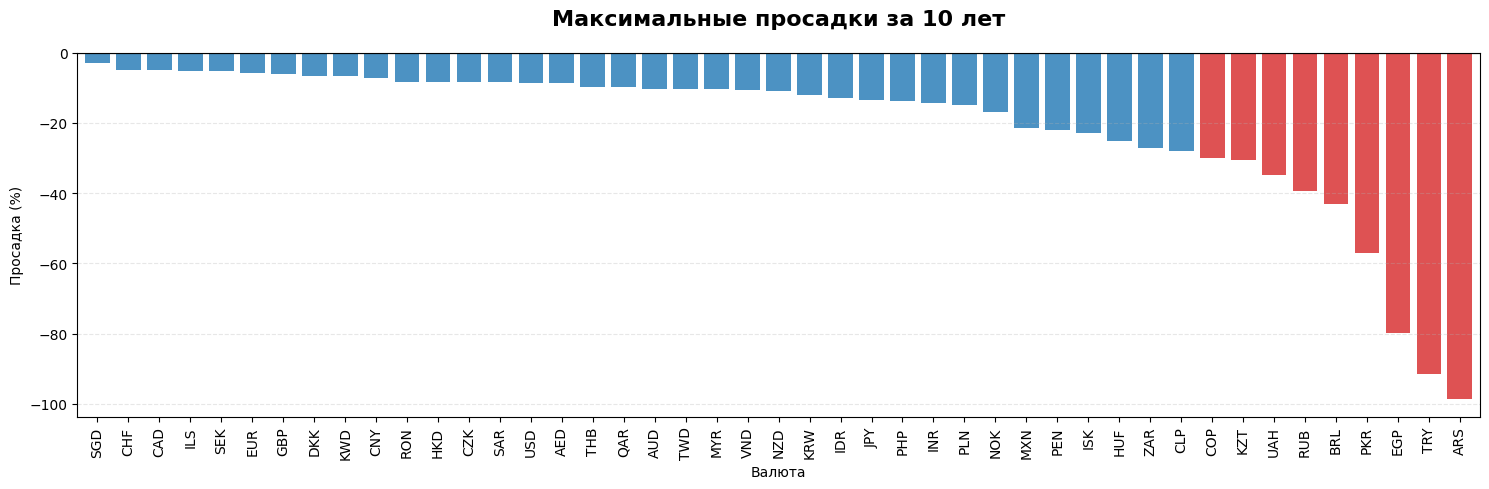

In [4]:
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# 1. Функция для генерации HTML-списка (с обновленными цветами и заголовками)
def get_html_list(tickers, values, title, color):
    html = f"<div style='flex: 1; min-width: 200px;'><b>{title}:</b><ul style='list-style: none; padding: 0; margin-top: 10px;'>"
    for t, v in zip(tickers, values):
        url = f"https://www.abscur.ru/p/2.html?abs={t}"
        # Для фаворитов используем синий (#1f77b4), для аутсайдеров красный (#d62728)
        html += f"<li style='margin-bottom: 5px;'><a href='{url}' target='_blank' style='color: {color}; text-decoration: none; font-weight: bold;'>● {t}</a>: {v:.2f}%</li>"
    html += "</ul></div>"
    return html

# 2. Основной цикл построения визуализаций
for period in date_periods.keys():
    # Данные для периода, сортировка: от 0 (стабильные) вниз к минусу (падающие)
    data_p = mdd_table[period].sort_values(ascending=False)
    
    # Построение диаграммы
    plt.figure(figsize=(15, 5))
    # Красим в красный только те, что входят в нижние 20% по значению (самые глубокие просадки)
    threshold = data_p.quantile(0.2)
    colors = ['#d62728' if x <= threshold else '#1f77b4' for x in data_p]
    
    bars = data_p.plot(kind='bar', color=colors, alpha=0.8, width=0.8)
    
    plt.title(f'Максимальные просадки за {period}', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Просадка (%)')
    plt.axhline(0, color='black', linewidth=0.8) # Линия нуля
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 3. Подготовка данных для списков (Топ-5)
    # Фавориты: значения ближе к 0 (максимальные в ряду отрицательных чисел)
    favorites = mdd_table[period].sort_values(ascending=False).head(5)
    # Аутсайдеры: самые глубокие просадки (минимальные значения)
    outsiders = mdd_table[period].sort_values(ascending=True).head(5)
    
    # 4. Формирование и вывод HTML-блока
    # Фавориты слева (синие), Аутсайдеры справа (красные)
    html_favorites = get_html_list(favorites.index, favorites.values, "Топ-5 Фаворитов (Min Drawdown)", "#1f77b4")
    html_outsiders = get_html_list(outsiders.index, outsiders.values, "Топ-5 Аутсайдеров (Max Drawdown)", "#d62728")
    
    display(HTML(f"""
        <div style='display: flex; gap: 30px; background: #ffffff; padding: 20px; 
             border: 1px solid #eee; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.05);'>
            {html_favorites}
            <div style='width: 1px; background: #eee;'></div>
            {html_outsiders}
        </div>
    """))
    print("\n" + "="*80 + "\n")